In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivsrijitverma/grayimgdata/texturedImg.jpg
/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg
/kaggle/input/datasets/shivsrijitverma/grayimgdata/smooth.jpg


In [2]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

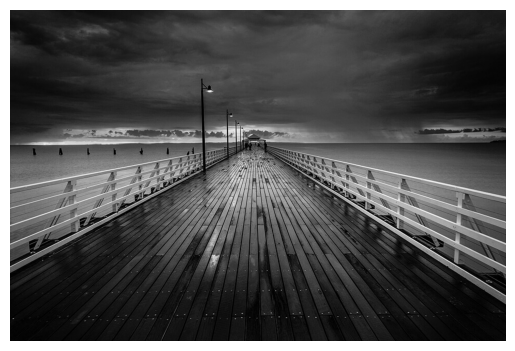

In [3]:
#Loading the image
img = cv2.imread("/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg", cv2.IMREAD_GRAYSCALE)

# Normalize to [0,1] for better numerical stability
img = img / 255.0

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [4]:
# Doing Gaussian Blur 
sigmas = [0.5, 1, 1.5]
blurred_images = []

for sigma in sigmas:
    ksize = int(6*sigma + 1)  #doing 6sigma so that we cover most of the bell curve area 
    # Ensure ksize is odd
    if ksize % 2 == 0:
        ksize += 1
    blurred = cv2.GaussianBlur(img, (ksize,ksize), sigma)
    blurred_images.append(blurred)

In [5]:
#Adding Gaussian Noise 
noise_sigma = 0.3
noisy_images = []

for blurred in blurred_images : 
    noise = np.random.normal(0,noise_sigma, blurred.shape)
    noisy = blurred + noise

    #clipping to valid range 
    noisy = np.clip(noisy, 0 , 1)
    noisy_images.append(noisy)

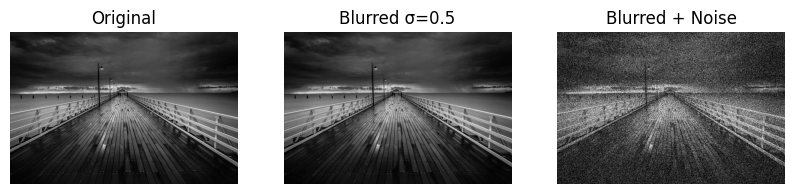

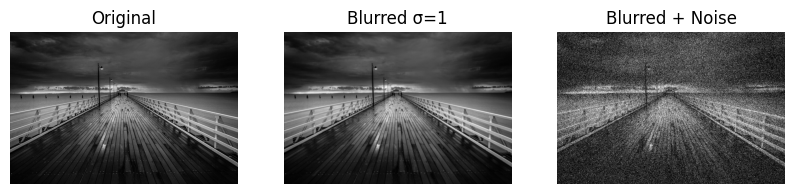

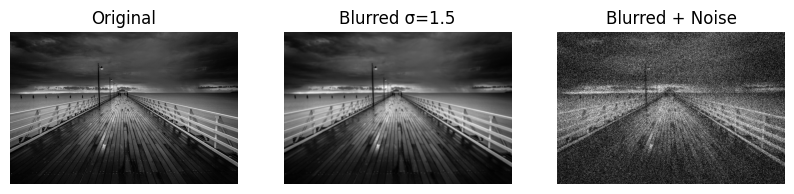

In [6]:
#dispaying blurred images 
for i, sigma in enumerate(sigmas):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(blurred_images[i], cmap='gray')
    plt.title(f"Blurred σ={sigma}")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(noisy_images[i], cmap='gray')
    plt.title("Blurred + Noise")

    plt.axis("off")
    plt.show()

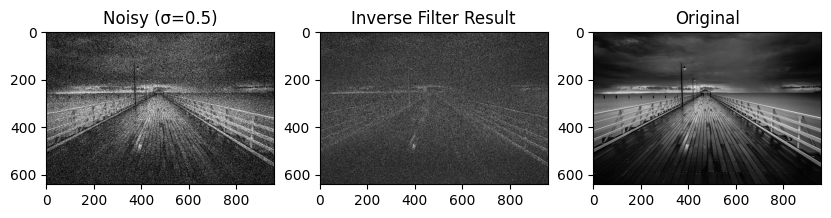

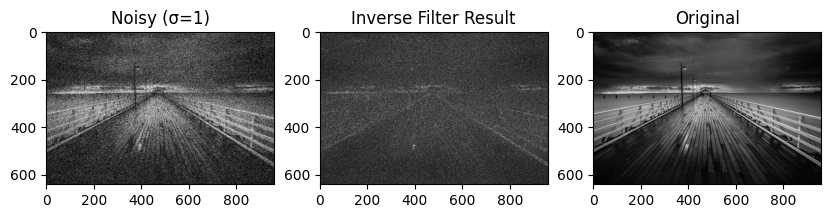

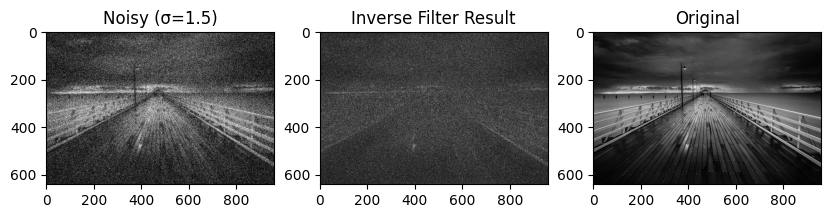

In [8]:
#applying inverse filtering to restore the image
def inverse_filter(noisy, sigma):
    rows , cols = noisy.shape 

    G = np.fft.fft2(noisy)
    G_shift = np.fft.fftshift(G)  # to move 0 frequency to center ...easier to create guassian filters using this 

    u = np.arange(rows)
    v = np.arange(cols)

    U, V = np.meshgrid(u,v, indexing='ij')

    D = ((U - rows/2)**2 + (V-cols/2)**2)

    H = np.exp(-D / (2 * sigma**2))

    H[H < 1e-5] = 1e-5

    F_hat = G_shift / H

    f_hat = np.fft.ifft2(np.fft.ifftshift(F_hat))

    return np.abs(f_hat)



inverse_results = []

for i, sigma in enumerate(sigmas):
    restored = inverse_filter(noisy_images[i], sigma)
    inverse_results.append(restored)

for i, sigma in enumerate(sigmas):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(noisy_images[i], cmap='gray')
    plt.title(f"Noisy (σ={sigma})")

    plt.subplot(1,3,2)
    plt.imshow(inverse_results[i], cmap='gray')
    plt.title("Inverse Filter Result")

    plt.subplot(1,3,3)
    plt.imshow(img, cmap='gray')
    plt.title("Original")

    plt.show()

In [19]:
# Weiner Filtering 
def wiener_filter(noisy, sigma, K=0.01):
    K = sigma**2
    rows, cols = noisy.shape 
    G = np.fft.fftshift(np.fft.fft2(noisy)) # convert to frequency domain and move (low frequency) to center
    
    u = np.fft.fftfreq(rows)
    v = np.fft.fftfreq(cols)
    U, V = np.meshgrid(u, v, indexing='ij')

    U = np.fft.fftshift(U)
    V = np.fft.fftshift(V)

    D2 = U**2 + V**2

    H = np.exp(-2 * (np.pi**2) * (sigma ** 2) * D2)

    H_conj = np.conj(H)
    W = H_conj / (np.abs(H)**2 + K )

    F_hat = W * G 

    f_hat = np.fft.ifft2(np.fft.ifftshift(F_hat))

    return np.abs(f_hat)

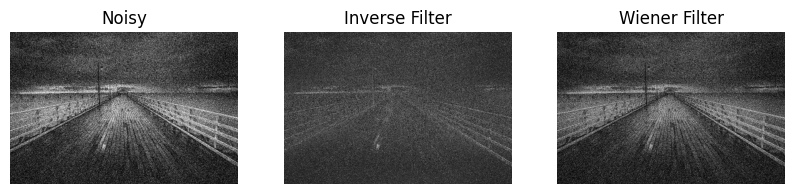

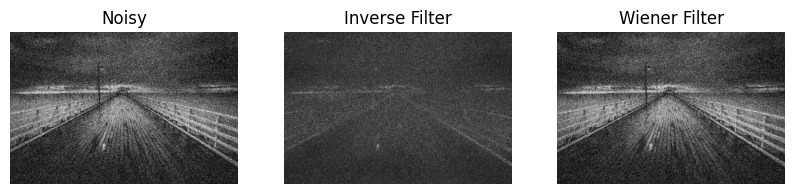

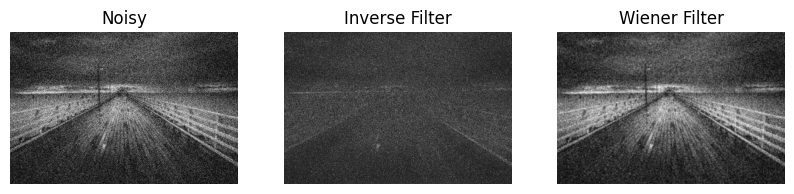

In [20]:
for i, sigma in enumerate(sigmas):
    inv = inverse_filter(noisy_images[i], sigma)
    wiener = wiener_filter(noisy_images[i], sigma)

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(noisy_images[i], cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(inv, cmap='gray')
    plt.title("Inverse Filter")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(wiener, cmap='gray')
    plt.title("Wiener Filter")
    plt.axis("off")

    plt.show()